In [1]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *
from python_scripts.plotting import *
from python_scripts.preprocessing import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [ ]:
train_set = pickle.load(open('sgr_set_log_reg_syn_100k','rb'))
train_set = train_set.sort_values('kappa', ascending=True).reset_index(drop=True).copy()
print(train_set.shape)
train_set.head() 

(99994, 3)


,y_true,y_pred,kappa
0,0,0,0.500010
1,0,1,0.500015
2,0,0,0.500020
3,0,1,0.500031
4,0,1,0.500031


In [3]:
test_set = pickle.load(open('sgr_set_log_reg', 'rb'))
print(test_set.shape)
test_set.head()

(212, 3)


,y_true,y_pred,kappa
186,1,0,0.505609
341,1,0,0.512266
44,1,1,0.520133
91,1,0,0.535762
267,1,1,0.543415


In [4]:
delta = 0.001

### Joint evolution of metrics with respect to $\theta$

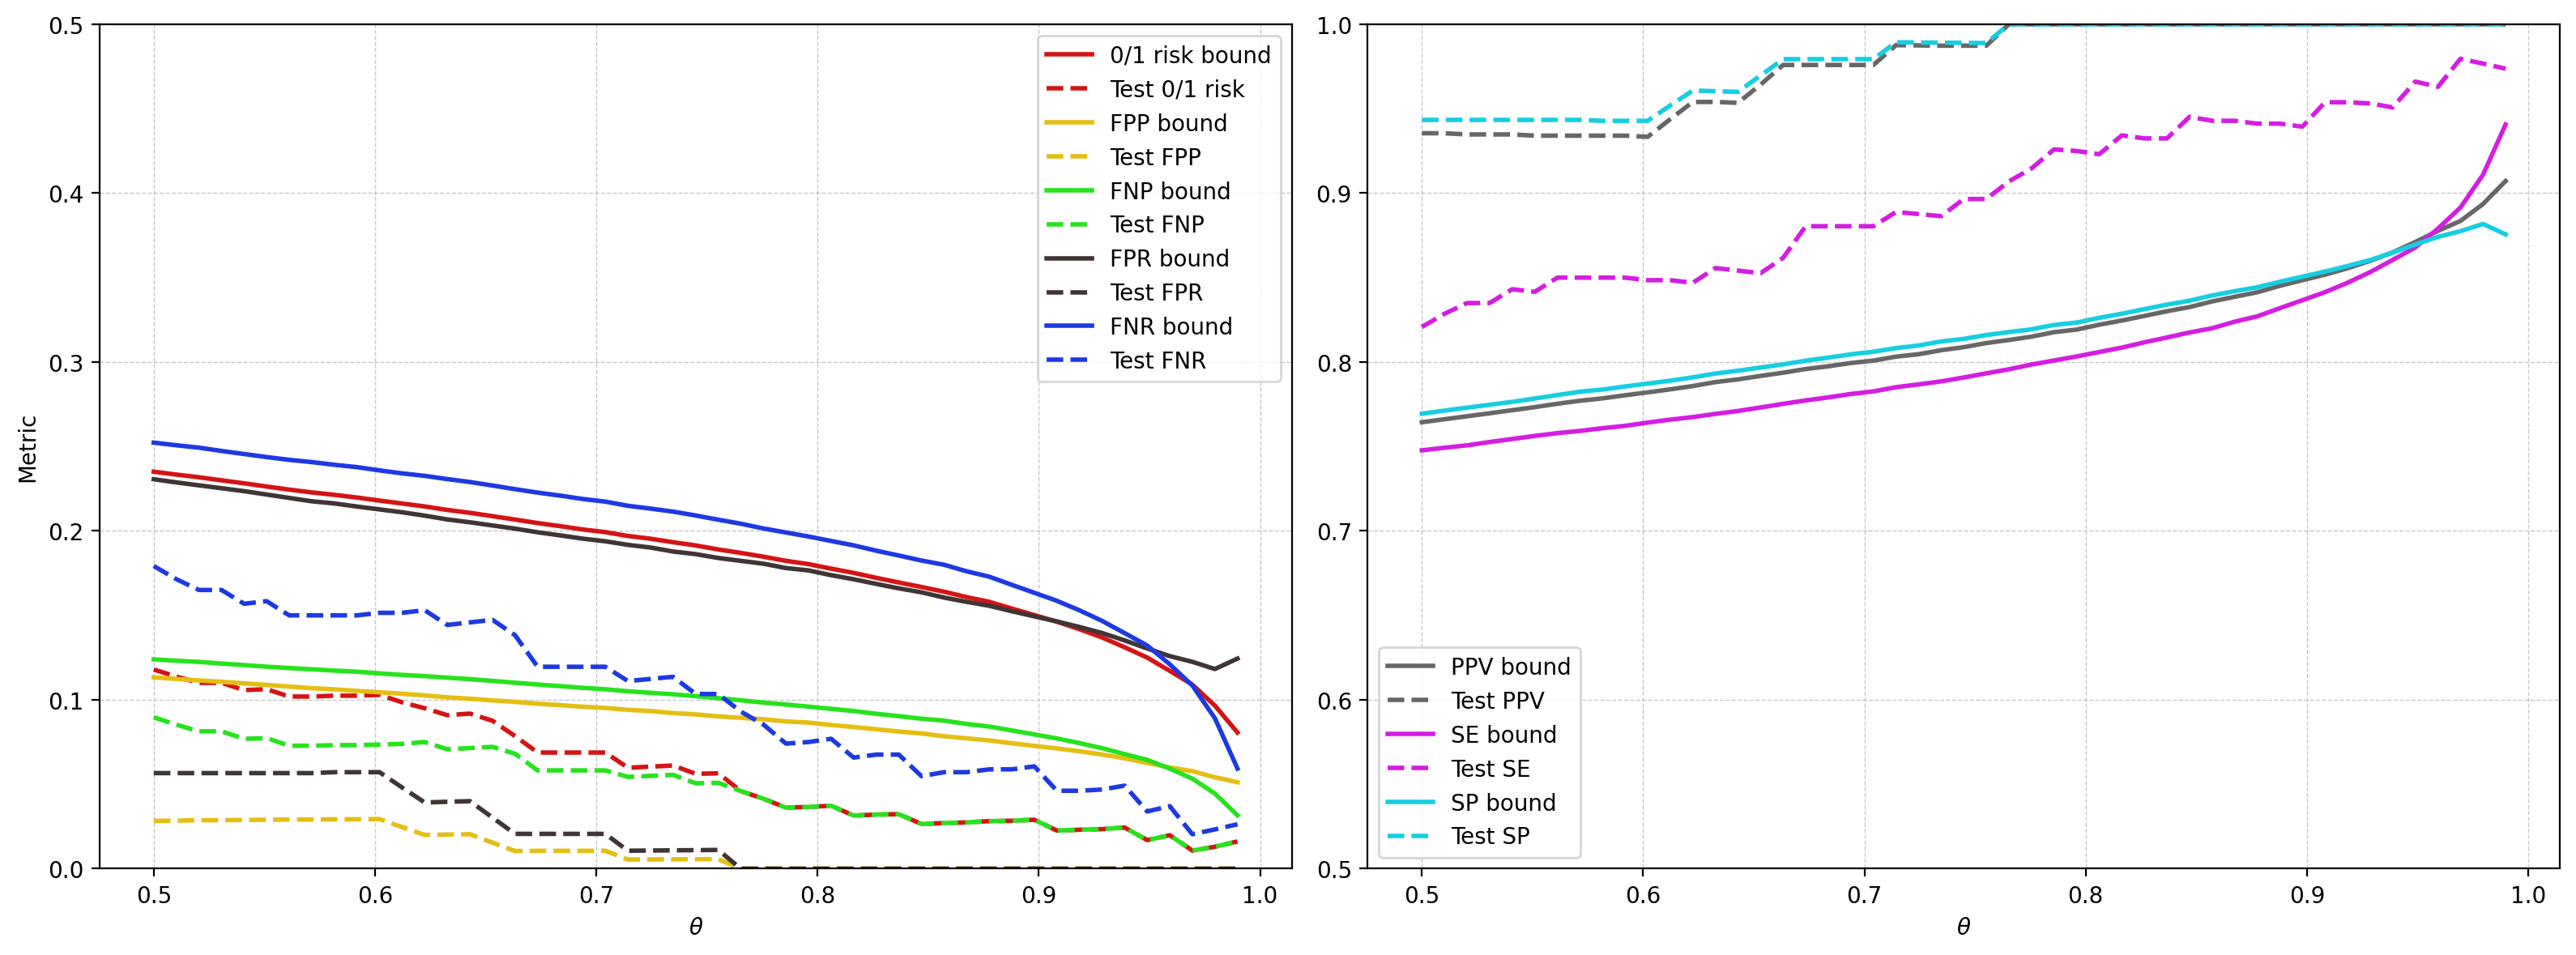

In [5]:
# Define color maps
color_map1 = {
    'standard': "#d51414",
    'FP': "#e5be12",
    'FN': "#27e21d",
    'FPR': "#403535",
    'FNR': "#1d3ae2"
}
label_map1 = {
    'standard': '0/1 risk',
    'FP': 'FPP',
    'FN': 'FNP',
    'FPR': 'FPR',
    'FNR': 'FNR'
}

color_map2 = {
    'SE': "#d51de2",
    'SP': "#16CEE2",
    'PPV': "#676767"
}

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# ----- First subplot -----
ax = axes[0]
for metric in ['standard', 'FP', 'FN', 'FPR', 'FNR']:
    color = color_map1[metric]
    
    thetas, bounds = bound_evo_w_theta(metric, train_set, delta, steps=50)
    ax.plot(thetas, bounds, color=color, label=label_map1[metric] + ' bound', linewidth=2)

    emp_metrics = []
    for theta in thetas:
        try:
            selected_set = test_set.loc[test_set.kappa >= theta].copy()
            emp_metrics.append(emp_metric(selected_set, metric=metric))
        except ValueError:
            emp_metrics.append(np.nan)

    ax.plot(thetas, emp_metrics, linestyle='--', color=color, label='Test ' + label_map1[metric], linewidth=2)

ax.set_ylim(0, 0.5)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('Metric')
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# ----- Second subplot -----
ax = axes[1]
for metric in ['PPV', 'SE', 'SP']:
    color = color_map2[metric]
    
    thetas, bounds = bound_evo_w_theta(metric, train_set, delta, steps=50)
    ax.plot(thetas, bounds, color=color, label=metric + ' bound', linewidth=2)

    emp_metrics = []
    for theta in thetas:
        try:
            selected_set = test_set.loc[test_set.kappa >= theta].copy()
            emp_metrics.append(emp_metric(selected_set, metric=metric))
        except ValueError:
            emp_metrics.append(np.nan)

    ax.plot(thetas, emp_metrics, linestyle='--', color=color, label='Test ' + metric, linewidth=2)

ax.set_ylim(0.5, 1)
ax.set_xlabel(r'$\theta$')
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()